In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import re
from scipy import stats
from matplotlib.path import Path as mPath
from scipy.stats import rankdata

from utils import get_itr_index, index_to_type, load_data, set_track_type


In [48]:
def parse_file(file_path):
    """
    Parse copied file name from your fixed copy function.

    Expected filename contains:
        first-pattern / first-position / pattern / position
        cut-off-0 / cut-off-top250
    """
    file_path = Path(file_path)
    name = file_path.stem

    if not file_path.name.startswith("neuro_type"):
        return None

    if "cut-off-0" in name:
        cutoff = "cut_off_0"
    elif "cut-off-top250" in name:
        cutoff = "cut_off_top250"
    else:
        return None

    if "first-pattern" in name:
        group = "first_pattern"
        is_first = True
        rule = "pattern"
    elif "first-position" in name:
        group = "first_position"
        is_first = True
        rule = "position"
    elif "pattern" in name:
        group = "pattern"
        is_first = False
        rule = "pattern"
    elif "position" in name:
        group = "position"
        is_first = False
        rule = "position"
    else:
        return None

    return {
        "mouse_id": file_path.parent.name,
        "file_path": str(file_path),
        "file_name": file_path.name,
        "cutoff": cutoff,
        "is_first": is_first,
        "rule": rule,
        "group": group,
    }


def select_files(
    data_root,
    cutoff=None,
    is_first=None,
    rule=None,
    group=None,
):
    """
    Select files from copied data folder.

    Parameters
    ----------
    data_root : str or Path
        data folder containing mouse folders.

    cutoff : None, "cut_off_0", or "cut_off_top250"
    is_first : None, True, or False
    rule : None, "pattern", or "position"
    group : None, "first_pattern", "first_position", "pattern", or "position"

    Returns
    -------
    df : pandas.DataFrame
    """
    data_root = Path(data_root)
    rows = []

    for mouse_dir in sorted(data_root.iterdir()):
        if not mouse_dir.is_dir():
            continue

        for file_path in sorted(mouse_dir.glob("neuro_type*.mat")):
            info = parse_file(file_path)

            if info is None:
                continue

            if cutoff is not None and info["cutoff"] != cutoff:
                continue

            if is_first is not None and info["is_first"] != is_first:
                continue

            if rule is not None and info["rule"] != rule:
                continue

            if group is not None and info["group"] != group:
                continue

            rows.append(info)

    return pd.DataFrame(rows)

In [49]:
def _corr_matrix_from_vectors(vectors, method="pearson"):
    X = np.stack(vectors, axis=0)  # (4, n_neurons)

    if method == "pearson":
        return np.corrcoef(X)

    elif method == "spearman":
        X = np.stack([rankdata(x) for x in X], axis=0)
        return np.corrcoef(X)

    else:
        raise ValueError("method must be 'pearson' or 'spearman'")


def compute_rule_corr_matrix(
    file_path,
    ana_tt=None,
    ana_bt=("Correct",),
    *,
    group_average="by_condition",
    method="pearson",
    track_type_id="auto",
):
    """
    Compute 4x4 correlation matrix for A1, A2, B1, B2 population vectors.

    For normal files:
        track_type_id = 0
        ["CAB", "CBA", "ACB", "BCA", "ABC", "BAC"]

    For first files:
        track_type_id = 1
        [
            "couple_ACB", "couple_BCA",
            "CAB", "CBA", "ACB", "BCA", "ABC", "BAC"
        ]

    ana_tt examples
    ---------------
    None:
        default to normal six track types.

    ("*",):
        use all available track types.
        For first files, this includes couple_ACB and couple_BCA.

    ("couple_*",):
        use only couple_ACB and couple_BCA.

    ("couple_ACB", "couple_BCA"):
        use couple data explicitly.
    """
    file_path = Path(file_path)

    if track_type_id == "auto":
        if "first" in file_path.stem:
            set_track_type(1)
        else:
            set_track_type(0)
    else:
        set_track_type(int(track_type_id))

    if ana_tt is None:
        ana_tt = ("ABC", "ACB", "BAC", "BCA", "CAB", "CBA")

    data = load_data(file_path)

    zones = data["zones"]
    s1 = int(np.floor(zones[1][0]))
    e1 = int(np.ceil(zones[2][0]))
    s2 = int(np.floor(zones[3][0]))
    e2 = int(np.ceil(zones[4][0]))

    def interval_mean(fr, start, end):
        T = fr.shape[2]
        start = max(0, min(T, start))
        end = max(0, min(T, end))

        if end <= start:
            return None

        return np.nanmean(fr[:, :, start:end], axis=2)

    cond_groups = {
        "AB_s1e1": [],
        "AB_s2e2": [],
        "BA_s1e1": [],
        "BA_s2e2": [],
    }

    trial_groups = {
        "AB_s1e1": [],
        "AB_s2e2": [],
        "BA_s1e1": [],
        "BA_s2e2": [],
    }

    for tt_idx, bt_idx in get_itr_index(ana_tt, ana_bt):
        fr = data["firing"][tt_idx][bt_idx]

        if fr is None:
            continue

        tt, _ = index_to_type(tt_idx, bt_idx)

        # couple_ACB -> ACB
        # couple_BCA -> BCA
        tt_base = tt.replace("couple_", "")

        if tt_base in ("CAB", "ACB", "ABC"):
            track = "AB"
        elif tt_base in ("CBA", "BCA", "BAC"):
            track = "BA"
        else:
            raise ValueError(f"Trial type not recognized: {tt}")

        m_s1e1 = interval_mean(fr, s1, e1)
        m_s2e2 = interval_mean(fr, s2, e2)

        if m_s1e1 is not None and m_s1e1.shape[1] > 0:
            key = f"{track}_s1e1"
            trial_groups[key].append(m_s1e1)
            cond_groups[key].append(np.nanmean(m_s1e1, axis=1))

        if m_s2e2 is not None and m_s2e2.shape[1] > 0:
            key = f"{track}_s2e2"
            trial_groups[key].append(m_s2e2)
            cond_groups[key].append(np.nanmean(m_s2e2, axis=1))

    labels = [
        "AB_s1e1",
        "BA_s2e2",
        "BA_s1e1",
        "AB_s2e2",
    ]

    vectors = {}

    for key in labels:
        if group_average == "by_condition":
            if len(cond_groups[key]) == 0:
                vectors[key] = None
            else:
                vectors[key] = np.nanmean(
                    np.stack(cond_groups[key], axis=0),
                    axis=0,
                )

        elif group_average == "by_trial":
            if len(trial_groups[key]) == 0:
                vectors[key] = None
            else:
                all_trials = np.concatenate(
                    trial_groups[key],
                    axis=1,
                )
                vectors[key] = np.nanmean(all_trials, axis=1)

        else:
            raise ValueError(
                "group_average must be 'by_condition' or 'by_trial'"
            )

    missing = [k for k in labels if vectors[k] is None]

    if len(missing) > 0:
        raise ValueError(
            f"These groups are empty or invalid: {missing}. "
            f"ana_tt = {ana_tt}"
        )

    corr = _corr_matrix_from_vectors(
        [vectors[k] for k in labels],
        method=method,
    )

    return {
        "labels": labels,
        "vectors": vectors,
        "corr": corr,
        "ana_tt": ana_tt,
        "track_type_id": 1 if "first" in file_path.stem else 0,
    }


RULE_LABEL_MAP = {
    "AB_s1e1": "A1",
    "BA_s2e2": "A2",
    "BA_s1e1": "B1",
    "AB_s2e2": "B2",
}


def _display_rule_labels(labels):
    return [RULE_LABEL_MAP.get(l, "?") for l in labels]


def _upper_tri_offdiag(mat):
    idx = np.triu_indices_from(mat, k=1)
    return mat[idx]


def _zscore_1d(x, eps=1e-12):
    x = np.asarray(x, dtype=float)
    return (x - np.nanmean(x)) / (np.nanstd(x) + eps)


def make_pure_pattern_position_matrices(labels):
    """
    Construct pure-pattern and pure-position template matrices.

    Parameters
    ----------
    labels : list of str
        Should be ["A1", "A2", "B1", "B2"].

    Returns
    -------
    pure_pattern : ndarray
        Same pattern = 1, different pattern = 0.

    pure_position : ndarray
        Same position = 1, different position = 0.
    """

    patterns = [lab[0] for lab in labels]
    positions = [lab[1:] for lab in labels]

    pure_pattern = np.equal.outer(patterns, patterns).astype(float)
    pure_position = np.equal.outer(positions, positions).astype(float)

    return pure_pattern, pure_position


def compute_pattern_position_value(
    result,
    *,
    value_type="standardized_beta",
    fit_intercept=True,
):
    """
    Compute pattern value and position value from a 4x4 correlation matrix.

    Only off-diagonal values are used.

    value_type
    ----------
    "standardized_beta":
        Z-score observed corr and templates first, then regress.
        This gives dimensionless template-matching coefficients.

    "raw_beta":
        Direct regression on raw correlation values.
        This measures absolute similarity gain.

    "template_corr":
        Direct correlation between observed matrix and each pure template.

    Model for beta methods
    ----------------------
        corr_offdiag =
            intercept
            + pattern_value * pure_pattern_offdiag
            + position_value * pure_position_offdiag
    """

    corr = result["corr"]
    labels = _display_rule_labels(result["labels"])

    pure_pattern, pure_position = make_pure_pattern_position_matrices(labels)

    y = _upper_tri_offdiag(corr)
    x_pattern = _upper_tri_offdiag(pure_pattern)
    x_position = _upper_tri_offdiag(pure_position)

    valid = (
        np.isfinite(y)
        & np.isfinite(x_pattern)
        & np.isfinite(x_position)
    )

    y = y[valid]
    x_pattern = x_pattern[valid]
    x_position = x_position[valid]

    if value_type == "raw_beta":
        y_fit = y.copy()
        xp_fit = x_pattern.copy()
        xq_fit = x_position.copy()

        X = np.column_stack([xp_fit, xq_fit])

        if fit_intercept:
            X = np.column_stack([np.ones(len(y_fit)), X])

        beta = np.linalg.lstsq(X, y_fit, rcond=None)[0]

        if fit_intercept:
            intercept = float(beta[0])
            pattern_value = float(beta[1])
            position_value = float(beta[2])
        else:
            intercept = 0.0
            pattern_value = float(beta[0])
            position_value = float(beta[1])

    elif value_type == "standardized_beta":
        y_fit = _zscore_1d(y)
        xp_fit = _zscore_1d(x_pattern)
        xq_fit = _zscore_1d(x_position)

        X = np.column_stack([xp_fit, xq_fit])

        if fit_intercept:
            X = np.column_stack([np.ones(len(y_fit)), X])

        beta = np.linalg.lstsq(X, y_fit, rcond=None)[0]

        if fit_intercept:
            intercept = float(beta[0])
            pattern_value = float(beta[1])
            position_value = float(beta[2])
        else:
            intercept = 0.0
            pattern_value = float(beta[0])
            position_value = float(beta[1])

    elif value_type == "template_corr":
        pattern_value = float(np.corrcoef(y, x_pattern)[0, 1])
        position_value = float(np.corrcoef(y, x_position)[0, 1])
        intercept = np.nan

    else:
        raise ValueError(
            "value_type must be 'standardized_beta', 'raw_beta', or 'template_corr'"
        )

    return {
        "labels": labels,
        "value_type": value_type,
        "pattern_value": pattern_value,
        "position_value": position_value,
        "intercept": intercept,
        "pure_pattern": pure_pattern,
        "pure_position": pure_position,
        "observed_offdiag": y,
        "pattern_template_offdiag": x_pattern,
        "position_template_offdiag": x_position,
    }


def plot_rule_corr_matrix(
    result,
    rule_name,
    *,
    values=None,
    figsize=(5.2, 4.8),
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    annotate=True,
):
    corr = result["corr"]
    labels = _display_rule_labels(result["labels"])

    fig, ax = plt.subplots(figsize=figsize)

    im = ax.imshow(
        corr,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
    )

    ax.set_xticks(np.arange(len(labels)))
    ax.set_yticks(np.arange(len(labels)))
    ax.set_xticklabels(labels)
    ax.set_yticklabels(labels)

    if annotate:
        for i in range(corr.shape[0]):
            for j in range(corr.shape[1]):
                ax.text(
                    j,
                    i,
                    f"{corr[i, j]:.2f}",
                    ha="center",
                    va="center",
                    fontsize=12,
                )

    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("correlation", fontsize=12)

    if values is None:
        title = f"{rule_name} correlation matrix"
    else:
        title = (
            f"{rule_name} correlation matrix\n"
            f"pattern value = {values['pattern_value']:.3f}, "
            f"position value = {values['position_value']:.3f}"
        )

    ax.set_title(title, fontsize=14)
    plt.tight_layout()
    plt.show()


def plot_template_matrices(
    labels=("A1", "A2", "B1", "B2"),
    *,
    figsize=(8.0, 3.6),
    cmap="Greys",
):
    """
    Optional helper for checking pure pattern and pure position matrices.
    """

    pure_pattern, pure_position = make_pure_pattern_position_matrices(labels)

    fig, axes = plt.subplots(1, 2, figsize=figsize)

    mats = [pure_pattern, pure_position]
    titles = ["Pure pattern template", "Pure position template"]

    for ax, mat, title in zip(axes, mats, titles):
        im = ax.imshow(mat, cmap=cmap, vmin=0, vmax=1)

        ax.set_xticks(np.arange(len(labels)))
        ax.set_yticks(np.arange(len(labels)))
        ax.set_xticklabels(labels)
        ax.set_yticklabels(labels)

        for i in range(mat.shape[0]):
            for j in range(mat.shape[1]):
                ax.text(
                    j,
                    i,
                    f"{mat[i, j]:.0f}",
                    ha="center",
                    va="center",
                    fontsize=11,
                )

        ax.set_title(title)

    plt.tight_layout()
    plt.show()



In [50]:
def analyze_one_rule_file(
    file_path,
    *,
    ana_tt=("ABC", "ACB", "BAC", "BCA", "CAB", "CBA"),
    ana_bt=("Correct",),
    group_average="by_trial",
    method="spearman",
    value_type="standardized_beta",
):
    """
    Analyze one copied neuro_type mat file.

    File name should contain:
        first-pattern / first-position / pattern / position
        cut-off-0 / cut-off-top250

    Returns
    -------
    row : dict
        Includes mouse_id, group, cutoff, pattern_value, position_value.
    """
    file_path = Path(file_path)

    meta = parse_file(file_path)
    if meta is None:
        raise ValueError(f"Cannot parse file label: {file_path}")

    result = compute_rule_corr_matrix(
        file_path=file_path,
        ana_tt=list(ana_tt),
        ana_bt=list(ana_bt),
        group_average=group_average,
        method=method,
    )

    values = compute_pattern_position_value(
        result,
        value_type=value_type,
    )

    return {
        **meta,
        "value_type": value_type,
        "method": method,
        "group_average": group_average,
        "pattern_value": values["pattern_value"],
        "position_value": values["position_value"],
        "intercept": values["intercept"],
    }
    
    
def analyze_selected_neuro_type_files(
    data_root,
    *,
    cutoff=None,
    is_first=None,
    rule=None,
    group=None,
    ana_tt=("ABC", "ACB", "BAC", "BCA", "CAB", "CBA"),
    ana_bt=("Correct",),
    group_average="by_trial",
    method="spearman",
    value_type="standardized_beta",
    skip_error=True,
    verbose=True,
):
    """
    Select copied neuro_type files and compute pattern / position similarity.

    Parameters
    ----------
    data_root : str or Path
        data folder containing mouse folders.

    cutoff : None, "cut_off_0", or "cut_off_top250"

    is_first : None, True, or False

    rule : None, "pattern", or "position"

    group : None, "first_pattern", "first_position", "pattern", or "position"

    Returns
    -------
    df : pandas.DataFrame
        One row = one mouse * one file/group.
    """
    df_files = select_files(
        data_root=data_root,
        cutoff=cutoff,
        is_first=is_first,
        rule=rule,
        group=group,
    )

    rows = []

    for _, r in df_files.iterrows():
        file_path = Path(r["file_path"])

        try:
            row = analyze_one_rule_file(
                file_path,
                ana_tt=ana_tt,
                ana_bt=ana_bt,
                group_average=group_average,
                method=method,
                value_type=value_type,
            )

            rows.append(row)

            if verbose:
                print(
                    f"[OK] {row['mouse_id']} | "
                    f"{row['group']} | "
                    f"{row['cutoff']} | "
                    f"pattern = {row['pattern_value']:.4f}, "
                    f"position = {row['position_value']:.4f}"
                )

        except Exception as e:
            if skip_error:
                print(f"[Skipped] {file_path.name}: {e}")
            else:
                raise e

    df = pd.DataFrame(rows)

    if len(df) == 0:
        raise ValueError("No valid files were analyzed.")

    return df

In [51]:
def analyze_couple_files(
    data_root,
    *,
    cutoff="cut_off_0",
    ana_bt=("Correct",),
    group_average="by_trial",
    method="spearman",
    value_type="standardized_beta",
    skip_error=True,
    verbose=True,
):
    """
    Analyze couple data from all first files.

    All couple data will be labeled as:
        group = "couple"

    It does not distinguish first_pattern or first_position.
    """
    df_files = select_files(
        data_root=data_root,
        cutoff=cutoff,
        is_first=True,
        rule=None,
        group=None,
    )

    rows = []

    for _, r in df_files.iterrows():
        file_path = Path(r["file_path"])

        try:
            result = compute_rule_corr_matrix(
                file_path=file_path,
                ana_tt=("couple_*",),
                ana_bt=list(ana_bt),
                group_average=group_average,
                method=method,
            )

            values = compute_pattern_position_value(
                result,
                value_type=value_type,
            )

            row = r.to_dict()

            row["source_group"] = row["group"]
            row["group"] = "couple"
            row["rule"] = "couple"
            row["ana_tt"] = "couple_*"

            row["value_type"] = value_type
            row["method"] = method
            row["group_average"] = group_average

            row["pattern_value"] = values["pattern_value"]
            row["position_value"] = values["position_value"]
            row["intercept"] = values["intercept"]

            rows.append(row)

            if verbose:
                print(
                    f"[OK couple] {row['mouse_id']} | "
                    f"from {row['source_group']} | "
                    f"{row['cutoff']} | "
                    f"pattern = {row['pattern_value']:.4f}, "
                    f"position = {row['position_value']:.4f}"
                )

        except Exception as e:
            if skip_error:
                print(f"[Skipped couple] {file_path.name}: {e}")
            else:
                raise e

    df = pd.DataFrame(rows)

    if len(df) == 0:
        raise ValueError("No valid couple files were analyzed.")

    return df


def add_couple_to_df(
    df,
    data_root,
    *,
    cutoff="cut_off_0",
    ana_bt=("Correct",),
    group_average="by_trial",
    method="spearman",
    value_type="standardized_beta",
    skip_error=True,
    verbose=True,
):
    """
    Add couple rows to an existing analyzed dataframe.
    """
    df_couple = analyze_couple_files(
        data_root=data_root,
        cutoff=cutoff,
        ana_bt=ana_bt,
        group_average=group_average,
        method=method,
        value_type=value_type,
        skip_error=skip_error,
        verbose=verbose,
    )

    return pd.concat(
        [df, df_couple],
        axis=0,
        ignore_index=True,
    )

In [52]:
def remove_top_right_spines(ax):
    """
    Remove top and right spines for cleaner plot.
    """
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


def p_to_stars(p):
    if p < 1e-3:
        return "***"
    if p < 1e-2:
        return "**"
    if p < 5e-2:
        return "*"
    return "n.s."


def add_sig_bracket(ax, x1, x2, y, h, text, lw=1.2):
    ax.plot(
        [x1, x1, x2, x2],
        [y, y + h, y + h, y],
        color="k",
        lw=lw,
        clip_on=False,
    )
    ax.text(
        (x1 + x2) / 2,
        y + h,
        text,
        ha="center",
        va="bottom",
    )


def get_group_color(group):
    colors = {
        "pattern": "#6ba3d6",
        "position": "#f0b35b",

        "first_pattern": "#b8d5ee",
        "first_position": "#f7d8a6",

        "couple": "#bdbdbd",
    }
    return colors[group]


def get_group_label(group):
    labels = {
        "pattern": "Pattern",
        "position": "Position",

        "first_pattern": "First to pattern",
        "first_position": "First to position",

        "couple": "Coupled",
    }
    return labels[group]


def get_two_groups_values(
    df,
    group1,
    group2,
    value_name,
    paired=True,
):
    """
    Get y1, y2 for two groups.

    If paired=True:
        pair by mouse_id.
    If paired=False:
        use all data independently.
    """
    d1 = df[df["group"] == group1][["mouse_id", value_name]].copy()
    d2 = df[df["group"] == group2][["mouse_id", value_name]].copy()

    if paired:
        d = pd.merge(
            d1,
            d2,
            on="mouse_id",
            suffixes=("_1", "_2"),
        )
        d = d.sort_values("mouse_id")

        y1 = d[f"{value_name}_1"].to_numpy(float)
        y2 = d[f"{value_name}_2"].to_numpy(float)

        return y1, y2, d["mouse_id"].tolist()

    else:
        y1 = d1[value_name].to_numpy(float)
        y2 = d2[value_name].to_numpy(float)

        y1 = y1[np.isfinite(y1)]
        y2 = y2[np.isfinite(y2)]

        return y1, y2, None


def two_group_boxplot(
    ax,
    y1,
    y2,
    group1,
    group2,
    *,
    paired=True,
    ylabel=None,
):
    """
    Draw one two-group boxplot.
    """
    colors = [get_group_color(group1), get_group_color(group2)]
    labels = [get_group_label(group1), get_group_label(group2)]

    box_width = 0.42

    box = ax.boxplot(
        [y1, y2],
        positions=[1, 2],
        widths=box_width,
        patch_artist=True,
        showfliers=False,
        medianprops=dict(color="k", lw=2),
        boxprops=dict(edgecolor="k", lw=1.2),
        whiskerprops=dict(color="k", lw=1.2),
        capprops=dict(color="k", lw=1.2),
        capwidths=0.18,
    )

    for patch, c in zip(box["boxes"], colors):
        patch.set_facecolor(c)
        patch.set_alpha(0.65)

    x1 = np.ones(len(y1))
    x2 = np.ones(len(y2)) * 2

    if paired:
        line_gap = 0.06

        x_left = 1 + box_width / 2 + line_gap
        x_right = 2 - box_width / 2 - line_gap

        for a, b in zip(y1, y2):
            ax.plot(
                [x_left, x_right],
                [a, b],
                color="#555555",
                lw=1.0,
                alpha=0.65,
                zorder=1,
            )
    else:
        rng = np.random.default_rng(0)
        x1 = x1 + rng.normal(0, 0.04, size=len(y1))
        x2 = x2 + rng.normal(0, 0.04, size=len(y2))

    ax.scatter(
        x1,
        y1,
        s=36,
        color=colors[0],
        edgecolor="white",
        linewidth=0.6,
        zorder=3,
    )

    ax.scatter(
        x2,
        y2,
        s=36,
        color=colors[1],
        edgecolor="white",
        linewidth=0.6,
        zorder=3,
    )

    if paired:
        stat, p = stats.ttest_rel(y1, y2)
    else:
        stat, p = stats.ttest_ind(y1, y2, equal_var=False)

    stars = p_to_stars(p)

    y_min = min(np.min(y1), np.min(y2))
    y_max = max(np.max(y1), np.max(y2))
    yr = y_max - y_min if y_max > y_min else 1.0

    y_br = y_max + 0.10 * yr
    h = 0.04 * yr

    add_sig_bracket(ax, 1, 2, y_br, h, stars)

    ax.set_xticks([1, 2])
    ax.set_xticklabels(labels, fontsize=13)
    ax.set_ylabel(ylabel, fontsize=15)

    ax.tick_params(
        axis="both",
        labelsize=13,
        width=1.2,
        length=4,
    )

    ax.set_xlim(0.5, 2.5)
    ax.set_ylim(y_min - 0.12 * yr, y_max + 0.24 * yr)

    remove_top_right_spines(ax)

    return {
        "stat": stat,
        "p": p,
        "stars": stars,
        "n": len(y1) if paired else (len(y1), len(y2)),
    }


def plot_two_groups_two_similarities(
    df,
    group1,
    group2,
    *,
    paired=True,
    figsize=(8.0, 5.0),
    title=None,
):
    fig, axes = plt.subplots(1, 2, figsize=figsize)

    stats_out = {}

    for ax, value_name, ylabel in zip(
        axes,
        ["pattern_value", "position_value"],
        ["Pattern similarity", "Position similarity"],
    ):
        y1, y2, mice = get_two_groups_values(
            df,
            group1,
            group2,
            value_name,
            paired=paired,
        )

        stat = two_group_boxplot(
            ax,
            y1,
            y2,
            group1,
            group2,
            paired=paired,
            ylabel=ylabel,
        )

        stat["y1"] = y1
        stat["y2"] = y2
        stat["mice"] = mice
        stat["group1"] = group1
        stat["group2"] = group2
        stat["value_name"] = value_name
        stat["paired"] = paired

        stats_out[value_name] = stat
        
        ax.set_ylim(0, 1.3)
        ax.set_yticks(np.arange(0, 1.21, 0.2))

    if title is not None:
        fig.suptitle(title, fontsize=17, y=1.03)

    plt.tight_layout()
    plt.show()

    return stats_out


In [53]:
def four_group_boxplot_one_value(
    ax,
    df,
    *,
    value_name="pattern_value",
    group_order=(
        "first_position",
        "position",
        "first_pattern",
        "pattern",
    ),
    comparisons=(
        ("first_position", "position"),
        ("first_pattern", "pattern"),
        ("first_position", "first_pattern"),
    ),
    ylabel=None,
    box_width=0.42,
):
    """
    Four-group unpaired boxplot for one value.

    Same style as two_group_boxplot:
        boxplot + scatter
        Welch t-test
        significance brackets
        no top/right spines
    """
    data = []
    ns = []

    for group in group_order:
        y = df.loc[df["group"] == group, value_name].to_numpy(float)
        y = y[np.isfinite(y)]
        data.append(y)
        ns.append(len(y))

    positions = np.arange(1, len(group_order) + 1)

    box = ax.boxplot(
        data,
        positions=positions,
        widths=box_width,
        patch_artist=True,
        showfliers=False,
        medianprops=dict(color="k", lw=2),
        boxprops=dict(edgecolor="k", lw=1.2),
        whiskerprops=dict(color="k", lw=1.2),
        capprops=dict(color="k", lw=1.2),
        capwidths=0.18,
    )

    for patch, group in zip(box["boxes"], group_order):
        patch.set_facecolor(get_group_color(group))
        patch.set_alpha(0.65)

    # scatter
    rng = np.random.default_rng(0)

    for x, group, y in zip(positions, group_order, data):
        if len(y) == 0:
            continue

        jitter = rng.normal(0, 0.04, size=len(y))

        ax.scatter(
            np.ones(len(y)) * x + jitter,
            y,
            s=36,
            color=get_group_color(group),
            alpha=0.9,
            edgecolor="white",
            linewidth=0.6,
            zorder=3,
        )

    # y range
    all_y = np.concatenate([y for y in data if len(y) > 0])

    y_min = np.min(all_y)
    y_max = np.max(all_y)
    yr = y_max - y_min if y_max > y_min else 1.0

    # statistics
    stats_out = {}

    group_to_x = {g: i + 1 for i, g in enumerate(group_order)}
    group_to_y = {g: data[i] for i, g in enumerate(group_order)}

    base_y = y_max + 0.10 * yr
    bracket_gap = 0.15 * yr
    bracket_h = 0.04 * yr

    for i, (g1, g2) in enumerate(comparisons):
        y1 = group_to_y[g1]
        y2 = group_to_y[g2]

        stat, p = stats.ttest_ind(
            y1,
            y2,
            equal_var=False,
            nan_policy="omit",
        )
        stars = p_to_stars(p)

        x1 = group_to_x[g1]
        x2 = group_to_x[g2]
        y_br = base_y + i * bracket_gap

        add_sig_bracket(
            ax,
            x1,
            x2,
            y_br,
            bracket_h,
            stars,
        )

        stats_out[(g1, g2)] = {
            "stat": stat,
            "p": p,
            "stars": stars,
            "n1": len(y1),
            "n2": len(y2),
        }

    xlabels = [
        f"{get_group_label(g)}\n(n={n})"
        for g, n in zip(group_order, ns)
    ]

    ax.set_xticks(positions)
    ax.set_xticklabels(xlabels, fontsize=13)

    if ylabel is None:
        ylabel = value_name.replace("_", " ").capitalize()

    ax.set_ylabel(ylabel, fontsize=15)

    ax.tick_params(
        axis="both",
        labelsize=13,
        width=1.2,
        length=4,
    )

    ax.set_xlim(0.5, len(group_order) + 0.5)
    ax.set_ylim(
        y_min - 0.12 * yr,
        base_y + len(comparisons) * bracket_gap + 0.08 * yr,
    )

    remove_top_right_spines(ax)

    return stats_out


def plot_four_group_two_similarities(
    df,
    *,
    group_order=(
        "first_position",
        "position",
        "first_pattern",
        "pattern",
    ),
    comparisons=(
        ("first_position", "position"),
        ("first_pattern", "pattern"),
        ("first_position", "first_pattern"),
    ),
    figsize=(11.0, 5.0),
    title=None,
):
    """
    Plot four groups for both:
        1. Pattern similarity
        2. Position similarity
    """
    fig, axes = plt.subplots(1, 2, figsize=figsize)

    pattern_stats = four_group_boxplot_one_value(
        axes[0],
        df,
        value_name="pattern_value",
        group_order=group_order,
        comparisons=comparisons,
        ylabel="Pattern similarity",
    )

    position_stats = four_group_boxplot_one_value(
        axes[1],
        df,
        value_name="position_value",
        group_order=group_order,
        comparisons=comparisons,
        ylabel="Position similarity",
    )

    if title is not None:
        fig.suptitle(title, fontsize=17, y=1.03)
    
    axes[0].set_ylim([0.0, 1.6])
    axes[0].set_yticks(np.arange(0, 1.61, 0.4))
    
    axes[1].set_ylim([0.0, 1.6])
    axes[1].set_yticks(np.arange(0, 1.61, 0.4))

    plt.tight_layout()
    plt.show()

    stats_out = {
        "pattern_value": pattern_stats,
        "position_value": position_stats,
    }

    for value_name, stats_dict in stats_out.items():
        print(f"\n========== {value_name} ==========")

        for (g1, g2), s in stats_dict.items():
            print(
                f"{get_group_label(g1)} vs {get_group_label(g2)} | "
                f"n = {s['n1']} vs {s['n2']}, "
                f"t = {s['stat']:.4f}, "
                f"p = {s['p']:.3e}, "
                f"{s['stars']}"
            )

    return stats_out


def analyze_and_plot_four_rule_groups(
    data_root,
    *,
    cutoff="cut_off_0",
    ana_tt=("ABC", "ACB", "BAC", "BCA", "CAB", "CBA"),
    ana_bt=("Correct",),
    group_average="by_trial",
    method="spearman",
    value_type="standardized_beta",
    skip_error=True,
):
    """
    Analyze and plot four groups:
        first_position
        position
        first_pattern
        pattern

    For one cutoff:
        cut_off_0
        or
        cut_off_top250
    """
    df = analyze_selected_neuro_type_files(
        data_root,
        cutoff=cutoff,
        is_first=None,
        rule=None,
        group=None,
        ana_tt=ana_tt,
        ana_bt=ana_bt,
        group_average=group_average,
        method=method,
        value_type=value_type,
        skip_error=skip_error,
        verbose=True,
    )

    group_order = [
        "first_position",
        "position",
        "first_pattern",
        "pattern",
    ]

    df = df[df["group"].isin(group_order)].copy()
    df["group"] = pd.Categorical(
        df["group"],
        categories=group_order,
        ordered=True,
    )
    df = df.sort_values(["group", "mouse_id"]).reset_index(drop=True)

    print("\n========== Summary ==========")
    print(
        df[
            [
                "mouse_id",
                "group",
                "cutoff",
                "pattern_value",
                "position_value",
                "file_name",
            ]
        ]
    )

    stats_out = plot_four_group_two_similarities(
        df,
        group_order=group_order,
        title=cutoff,
    )

    return df, stats_out

In [54]:
def get_couple_first_pair_values(
    df,
    *,
    first_group,
    value_name,
):
    """
    Get paired values between:
        couple from first_group source
        first_group
    """
    d_couple = df[
        (df["group"] == "couple") &
        (df["source_group"] == first_group)
    ][["mouse_id", value_name]].copy()

    d_first = df[
        df["group"] == first_group
    ][["mouse_id", value_name]].copy()

    d = pd.merge(
        d_couple,
        d_first,
        on="mouse_id",
        suffixes=("_couple", "_first"),
    )

    d = d.sort_values("mouse_id")

    y_couple = d[f"{value_name}_couple"].to_numpy(float)
    y_first = d[f"{value_name}_first"].to_numpy(float)

    return y_couple, y_first, d["mouse_id"].tolist()


def plot_couple_first_pattern_position_together(
    df,
    *,
    figsize=(10.5, 5.0),
    title=None,
):
    """
    Four groups in one plot:

        1. Couple from first_pattern
        2. First pattern
        3. Couple from first_position
        4. First position

    Comparisons:
        1 vs 2: paired
        3 vs 4: paired
        1 vs 3: unpaired couple comparison
    """
    fig, axes = plt.subplots(1, 2, figsize=figsize)

    stats_out = {}

    for ax, value_name, ylabel in zip(
        axes,
        ["pattern_value", "position_value"],
        ["Pattern similarity", "Position similarity"],
    ):
        # paired: couple from first_pattern vs first_pattern
        y_couple_pat, y_first_pat, mice_pat = get_couple_first_pair_values(
            df,
            first_group="first_pattern",
            value_name=value_name,
        )

        # paired: couple from first_position vs first_position
        y_couple_pos, y_first_pos, mice_pos = get_couple_first_pair_values(
            df,
            first_group="first_position",
            value_name=value_name,
        )

        data = [
            y_couple_pat,
            y_first_pat,
            y_couple_pos,
            y_first_pos,
        ]

        positions = [1, 2, 3.4, 4.4]

        labels = [
            "Couple",
            "Pattern",
            "Couple",
            "Position",
        ]

        colors = [
            get_group_color("couple"),
            get_group_color("first_pattern"),
            get_group_color("couple"),
            get_group_color("first_position"),
        ]

        box_width = 0.42

        box = ax.boxplot(
            data,
            positions=positions,
            widths=box_width,
            patch_artist=True,
            showfliers=False,
            medianprops=dict(color="k", lw=2),
            boxprops=dict(edgecolor="k", lw=1.2),
            whiskerprops=dict(color="k", lw=1.2),
            capprops=dict(color="k", lw=1.2),
            capwidths=0.18,
        )

        for patch, c in zip(box["boxes"], colors):
            patch.set_facecolor(c)
            patch.set_alpha(0.65)

        # paired lines, clipped between boxes
        line_gap = 0.06

        def draw_pair_lines(x1_box, x2_box, y1, y2):
            x1_line = x1_box + box_width / 2 + line_gap
            x2_line = x2_box - box_width / 2 - line_gap

            for a, b in zip(y1, y2):
                ax.plot(
                    [x1_line, x2_line],
                    [a, b],
                    color="#555555",
                    lw=1.0,
                    alpha=0.65,
                    zorder=1,
                )

        draw_pair_lines(1, 2, y_couple_pat, y_first_pat)
        draw_pair_lines(3.4, 4.4, y_couple_pos, y_first_pos)

        # scatter
        rng = np.random.default_rng(0)

        for x, y, c in zip(positions, data, colors):
            jitter = rng.normal(0, 0.04, size=len(y))

            ax.scatter(
                np.ones(len(y)) * x + jitter,
                y,
                s=36,
                color=c,
                alpha=0.9,
                edgecolor="white",
                linewidth=0.6,
                zorder=3,
            )

        # statistics
        stat_pat, p_pat = stats.ttest_rel(y_couple_pat, y_first_pat)
        stat_pos, p_pos = stats.ttest_rel(y_couple_pos, y_first_pos)

        # couple from first_pattern vs couple from first_position
        stat_couple, p_couple = stats.ttest_ind(
            y_couple_pat,
            y_couple_pos,
            equal_var=False,
        )

        # first_pattern vs first_position
        stat_first, p_first = stats.ttest_ind(
            y_first_pat,
            y_first_pos,
            equal_var=False,
        )

        stars_pat = p_to_stars(p_pat)
        stars_pos = p_to_stars(p_pos)
        stars_couple = p_to_stars(p_couple)
        stars_first = p_to_stars(p_first)

        all_y = np.concatenate(data)
        y_min = np.min(all_y)
        y_max = np.max(all_y)
        yr = y_max - y_min if y_max > y_min else 1.0

        y_low_br = y_max + 0.10 * yr
        y_mid_br = y_max + 0.25 * yr
        y_high_br = y_max + 0.40 * yr
        h = 0.04 * yr

        # paired brackets
        add_sig_bracket(ax, 1, 2, y_low_br, h, stars_pat)
        add_sig_bracket(ax, 3.4, 4.4, y_low_br, h, stars_pos)

        # couple vs couple, unpaired
        add_sig_bracket(ax, 1, 3.4, y_mid_br, h, stars_couple)

        # pattern vs position, unpaired
        add_sig_bracket(ax, 2, 4.4, y_high_br, h, stars_first)

        ax.set_xticks(positions)
        ax.set_xticklabels(labels, fontsize=13)

        ax.set_ylabel(ylabel, fontsize=15)

        ax.tick_params(
            axis="both",
            labelsize=13,
            width=1.2,
            length=4,
        )

        ax.set_xlim(0.4, 5.0)
        ax.set_ylim([0.0, 1.7])
        ax.set_yticks(np.arange(0, 1.61, 0.4))

        remove_top_right_spines(ax)

        stats_out[value_name] = {
            "couple_vs_first_pattern": {
                "stat": stat_pat,
                "p": p_pat,
                "stars": stars_pat,
                "n": len(y_couple_pat),
                "mice": mice_pat,
                "y_couple": y_couple_pat,
                "y_first": y_first_pat,
            },
            "couple_vs_first_position": {
                "stat": stat_pos,
                "p": p_pos,
                "stars": stars_pos,
                "n": len(y_couple_pos),
                "mice": mice_pos,
                "y_couple": y_couple_pos,
                "y_first": y_first_pos,
            },
            "couple_pattern_source_vs_position_source": {
                "stat": stat_couple,
                "p": p_couple,
                "stars": stars_couple,
                "n": (len(y_couple_pat), len(y_couple_pos)),
                "y1": y_couple_pat,
                "y2": y_couple_pos,
            },
            "first_pattern_vs_first_position": {
                "stat": stat_first,
                "p": p_first,
                "stars": stars_first,
                "n": (len(y_first_pat), len(y_first_pos)),
                "y1": y_first_pat,
                "y2": y_first_pos,
            },
        }

    if title is not None:
        fig.suptitle(title, fontsize=17, y=1.03)

    plt.tight_layout()
    plt.show()

    for value_name, s in stats_out.items():
        print(f"\n========== {value_name} ==========")

        print(
            f"Couple from first_pattern vs First pattern | "
            f"n = {s['couple_vs_first_pattern']['n']}, "
            f"t = {s['couple_vs_first_pattern']['stat']:.4f}, "
            f"p = {s['couple_vs_first_pattern']['p']:.3e}, "
            f"{s['couple_vs_first_pattern']['stars']}"
        )

        print(
            f"Couple from first_position vs First position | "
            f"n = {s['couple_vs_first_position']['n']}, "
            f"t = {s['couple_vs_first_position']['stat']:.4f}, "
            f"p = {s['couple_vs_first_position']['p']:.3e}, "
            f"{s['couple_vs_first_position']['stars']}"
        )

        print(
            f"Couple from first_pattern vs Couple from first_position | "
            f"n = {s['couple_pattern_source_vs_position_source']['n'][0]} vs "
            f"{s['couple_pattern_source_vs_position_source']['n'][1]}, "
            f"t = {s['couple_pattern_source_vs_position_source']['stat']:.4f}, "
            f"p = {s['couple_pattern_source_vs_position_source']['p']:.3e}, "
            f"{s['couple_pattern_source_vs_position_source']['stars']}"
        )
        
        print(
            f"First pattern vs First position | "
            f"n = {s['first_pattern_vs_first_position']['n'][0]} vs "
            f"{s['first_pattern_vs_first_position']['n'][1]}, "
            f"t = {s['first_pattern_vs_first_position']['stat']:.4f}, "
            f"p = {s['first_pattern_vs_first_position']['p']:.3e}, "
            f"{s['first_pattern_vs_first_position']['stars']}"
        )

    return stats_out

[OK] HP01 | first_pattern | cut_off_0 | pattern = 0.7259, position = 1.1313
[OK] HP01 | pattern | cut_off_0 | pattern = 0.5604, position = 1.1495
[OK] HP01 | position | cut_off_0 | pattern = 0.3559, position = 1.1196
[OK] HP02 | position | cut_off_0 | pattern = 0.3230, position = 1.1143
[OK] HP02 | first_position | cut_off_0 | pattern = 0.4294, position = 1.1309
[OK] HP02 | pattern | cut_off_0 | pattern = 1.1229, position = 0.5673
[OK] HP03 | first_pattern | cut_off_0 | pattern = 1.0838, position = 0.3679
[OK] HP07 | first_position | cut_off_0 | pattern = 0.1714, position = 1.0736
[OK] HP07 | pattern | cut_off_0 | pattern = 1.0193, position = 0.9386
[OK] HP07 | position | cut_off_0 | pattern = 0.2150, position = 1.0871
[OK] HP08 | pattern | cut_off_0 | pattern = 1.0517, position = 0.9026
[OK] HP08 | position | cut_off_0 | pattern = 0.7591, position = 1.1289
[OK] HP24 | first_pattern | cut_off_0 | pattern = 0.0740, position = 1.0328
[OK] HP24 | pattern | cut_off_0 | pattern = 0.1424, po

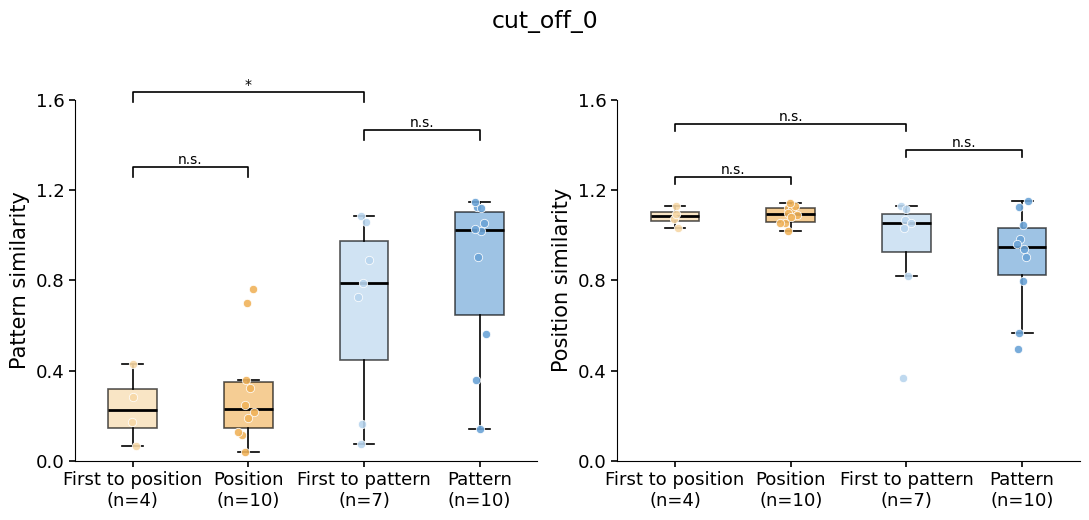


========== pattern_value ==========
First to position vs Position | n = 4 vs 10, t = -0.6427, p = 5.366e-01, n.s.
First to pattern vs Pattern | n = 7 vs 10, t = -0.8467, p = 4.138e-01, n.s.
First to position vs First to pattern | n = 4 vs 7, t = -2.5868, p = 3.114e-02, *

========== position_value ==========
First to position vs Position | n = 4 vs 10, t = -0.3144, p = 7.652e-01, n.s.
First to pattern vs Pattern | n = 7 vs 10, t = 0.3651, p = 7.219e-01, n.s.
First to position vs First to pattern | n = 4 vs 7, t = 1.3292, p = 2.286e-01, n.s.
[OK couple] HP01 | from first_pattern | cut_off_0 | pattern = 0.4874, position = 1.1428
[OK couple] HP02 | from first_position | cut_off_0 | pattern = 0.4056, position = 1.1132
[OK couple] HP03 | from first_pattern | cut_off_0 | pattern = 0.9137, position = 0.9442
[OK couple] HP07 | from first_position | cut_off_0 | pattern = 0.2274, position = 1.0898
[OK couple] HP24 | from first_pattern | cut_off_0 | pattern = 0.0464, position = 1.0221
[OK couple

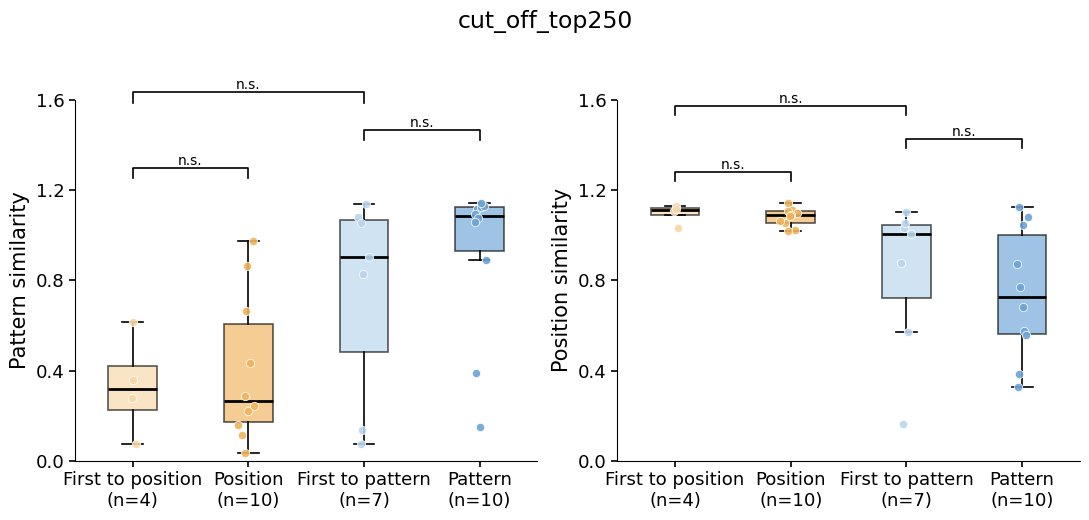


========== pattern_value ==========
First to position vs Position | n = 4 vs 10, t = -0.4528, p = 6.623e-01, n.s.
First to pattern vs Pattern | n = 7 vs 10, t = -0.8494, p = 4.139e-01, n.s.
First to position vs First to pattern | n = 4 vs 7, t = -2.0373, p = 7.222e-02, n.s.

========== position_value ==========
First to position vs Position | n = 4 vs 10, t = 0.6989, p = 5.151e-01, n.s.
First to pattern vs Pattern | n = 7 vs 10, t = 0.5524, p = 5.913e-01, n.s.
First to position vs First to pattern | n = 4 vs 7, t = 2.0265, p = 8.659e-02, n.s.
[OK couple] HP01 | from first_pattern | cut_off_top250 | pattern = 0.9115, position = 1.0634
[OK couple] HP02 | from first_position | cut_off_top250 | pattern = 0.6345, position = 1.0843
[OK couple] HP03 | from first_pattern | cut_off_top250 | pattern = 1.0797, position = 0.5007
[OK couple] HP07 | from first_position | cut_off_top250 | pattern = 0.2913, position = 1.1103
[OK couple] HP24 | from first_pattern | cut_off_top250 | pattern = 0.0464, p

In [55]:
data_root = "../../data/HPC_2p/"

df_cut0, stats_cut0 = analyze_and_plot_four_rule_groups(
    data_root=data_root,
    cutoff="cut_off_0",
)

df_cut0 = add_couple_to_df(
    df_cut0,
    data_root=data_root,
    cutoff="cut_off_0",
)

df_top250, stats_top250 = analyze_and_plot_four_rule_groups(
    data_root=data_root,
    cutoff="cut_off_top250",
)

df_top250 = add_couple_to_df(
    df_top250,
    data_root=data_root,
    cutoff="cut_off_top250",
)

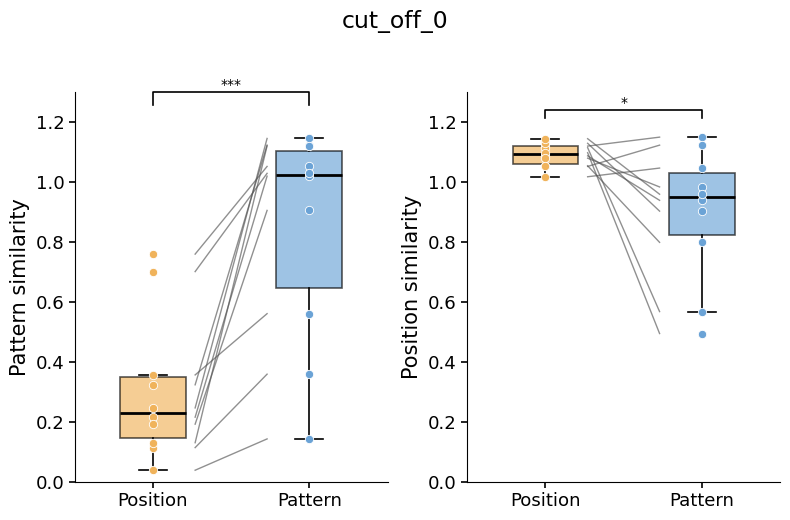

In [56]:
stats_0 = plot_two_groups_two_similarities(
    df_cut0,
    group1="position",
    group2="pattern",
    paired=True,
    title="cut_off_0",
)


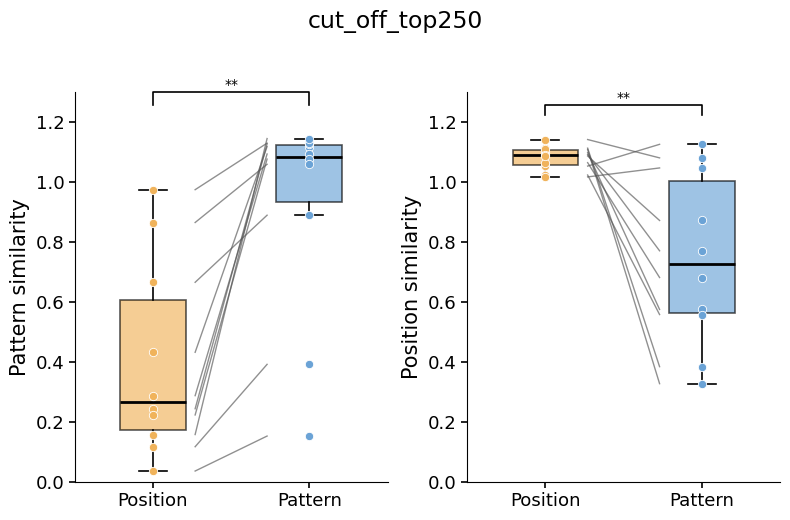

In [57]:
stats_pair = plot_two_groups_two_similarities(
    df_top250,
    group1="position",
    group2="pattern",
    paired=True,
    title="cut_off_top250",
)


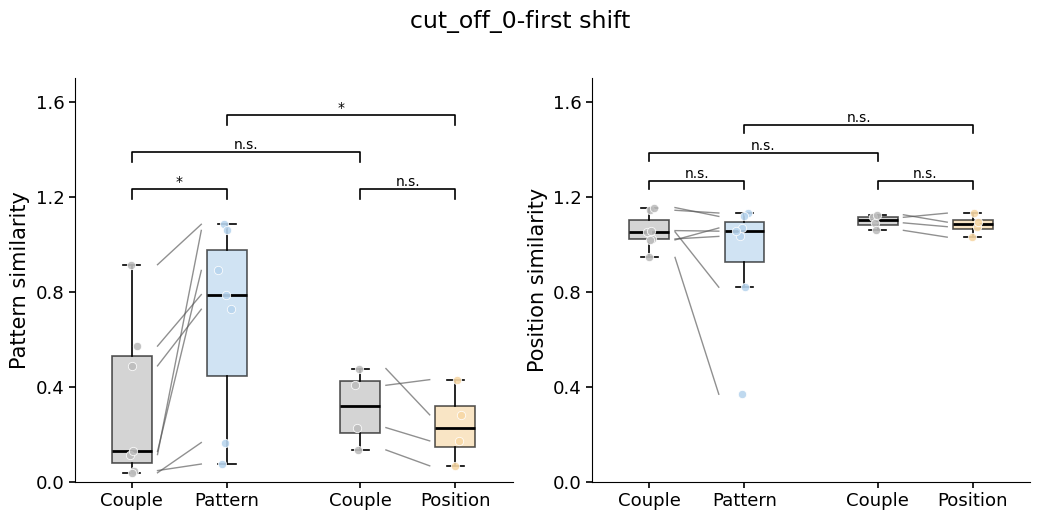


========== pattern_value ==========
Couple from first_pattern vs First pattern | n = 7, t = -2.6786, p = 3.660e-02, *
Couple from first_position vs First position | n = 4, t = 1.6251, p = 2.026e-01, n.s.
Couple from first_pattern vs Couple from first_position | n = 7 vs 4, t = 0.1168, p = 9.096e-01, n.s.
First pattern vs First position | n = 7 vs 4, t = 2.5868, p = 3.114e-02, *

========== position_value ==========
Couple from first_pattern vs First pattern | n = 7, t = 1.3532, p = 2.247e-01, n.s.
Couple from first_position vs First position | n = 4, t = 1.3014, p = 2.840e-01, n.s.
Couple from first_pattern vs Couple from first_position | n = 7 vs 4, t = -1.2936, p = 2.299e-01, n.s.
First pattern vs First position | n = 7 vs 4, t = -1.3292, p = 2.286e-01, n.s.


In [58]:
stats_cut0 = plot_couple_first_pattern_position_together(
    df_cut0,
    title="cut_off_0-first shift",
)

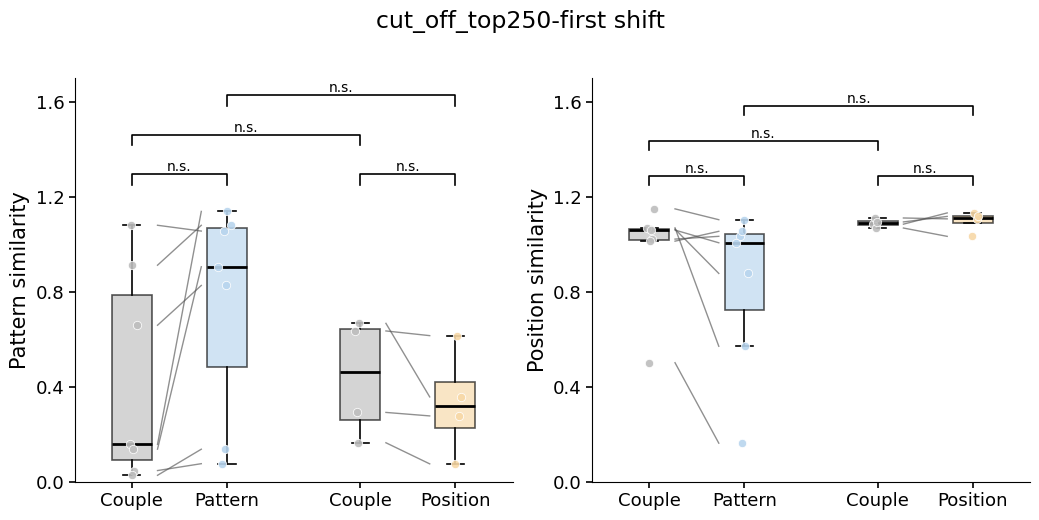


========== pattern_value ==========
Couple from first_pattern vs First pattern | n = 7, t = -2.1098, p = 7.939e-02, n.s.
Couple from first_position vs First position | n = 4, t = 1.5636, p = 2.159e-01, n.s.
Couple from first_pattern vs Couple from first_position | n = 7 vs 4, t = -0.0388, p = 9.699e-01, n.s.
First pattern vs First position | n = 7 vs 4, t = 2.0373, p = 7.222e-02, n.s.

========== position_value ==========
Couple from first_pattern vs First pattern | n = 7, t = 2.0167, p = 9.032e-02, n.s.
Couple from first_position vs First position | n = 4, t = -0.4477, p = 6.847e-01, n.s.
Couple from first_pattern vs Couple from first_position | n = 7 vs 4, t = -1.2976, p = 2.410e-01, n.s.
First pattern vs First position | n = 7 vs 4, t = -2.0265, p = 8.659e-02, n.s.


In [59]:
stats_top250 = plot_couple_first_pattern_position_together(
    df_top250,
    title="cut_off_top250-first shift",
)